Predicción de Abandono (Churn)!

Para esto, usaremos un modelo de clasificación (Random Forest Classifier) y aprenderemos un concepto avanzado para entrevistas: evitar el Data Leakage (Fuga de Datos).

1. Importar librerías y conectar a la BD

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sqlalchemy import create_engine, text
import os
from dotenv import load_dotenv

sns.set_theme(style="whitegrid")

load_dotenv('../.env')
engine = create_engine(f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}")

print("✅ Librerías de Clasificación (Churn) cargadas.")

C:\Users\Andres\AppData\Local\Temp\ipykernel_5956\3196748350.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


✅ Librerías de Clasificación (Churn) cargadas.


2. Definir el "Churn" y evitar la Fuga de Datos (Data Leakage)

Como nuestro dataset no tiene una columna que diga "Se fue de la empresa: Sí/No", vamos a crear una regla de negocio: Si un cliente no ha comprado en más de 180 días, lo consideramos en "Churn" (Abandonó).

In [4]:
# Traemos la vista RFM que creamos en la Fase 7
df_churn = pd.read_sql("SELECT * FROM vw_customer_rfm_prep;", engine)
df_churn = df_churn.fillna({'frequency': 0, 'monetary': 0, 'recency_dias': 999})

# 1. Crear variable objetivo (Target) con LÍMITE DINÁMICO
# Usamos la mediana de inactividad de tus clientes reales
LIMITE_DIAS = df_churn['recency_dias'].median()
df_churn['churn'] = (df_churn['recency_dias'] > LIMITE_DIAS).astype(int)

# 2. Crear nueva variable (Feature Engineering): Ticket Promedio
df_churn['ticket_promedio'] = df_churn['monetary'] / df_churn['frequency'].replace(0, 1)

print(f"Límite dinámico de días para considerar Churn: {LIMITE_DIAS} días")
print(f"Total clientes: {len(df_churn)}")
print(f"Clientes activos (0): {len(df_churn[df_churn['churn'] == 0])}")
print(f"Clientes en riesgo (1): {len(df_churn[df_churn['churn'] == 1])}")

Límite dinámico de días para considerar Churn: 653.5 días
Total clientes: 326
Clientes activos (0): 163
Clientes en riesgo (1): 163


3. Entrenamiento del Modelo (Random Forest)

In [5]:
# Variables predictoras (X) SIN recency_dias
features = ['frequency', 'monetary', 'ticket_promedio']
X = df_churn[features]
y = df_churn['churn']

# Dividimos: 70% para que el modelo estudie (Train), 30% para tomarle un examen (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Entrenar el Bosque Aleatorio
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo_rf.fit(X_train, y_train)

# Hacer predicciones sobre el 30% de prueba
predicciones = modelo_rf.predict(X_test)
probabilidades = modelo_rf.predict_proba(X_test)[:, 1] # Probabilidad del 0% al 100% de abandonar

print("✅ Modelo entrenado exitosamente.")

✅ Modelo entrenado exitosamente.


4. Evaluación del Modelo (La Matriz de Confusión)

No solo importa el "Accuracy" (Precisión global). En negocios, es más grave dejar que un cliente se vaya (Falso Negativo) que mandarle un cupón de descuento a alguien que no se iba a ir (Falso Positivo).

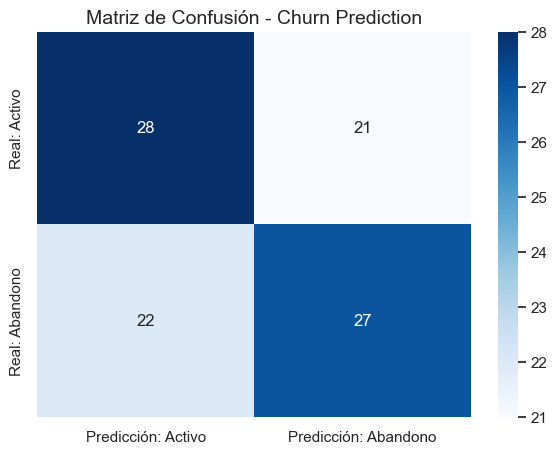

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

  Activo (0)       0.56      0.57      0.57        49
Abandono (1)       0.56      0.55      0.56        49

    accuracy                           0.56        98
   macro avg       0.56      0.56      0.56        98
weighted avg       0.56      0.56      0.56        98



In [6]:
# Generar matriz de confusión
cm = confusion_matrix(y_test, predicciones)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicción: Activo', 'Predicción: Abandono'], 
            yticklabels=['Real: Activo', 'Real: Abandono'])
plt.title('Matriz de Confusión - Churn Prediction', fontsize=14)
plt.show()

# Reporte de métricas
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, predicciones, target_names=['Activo (0)', 'Abandono (1)']))

5. Guardar el Riesgo de Fuga en PostgreSQL

Vamos a predecir la probabilidad de abandono para absolutamente todos los clientes y lo guardaremos en la base de datos. ¡Esto es lo que verá el equipo de Marketing en Power BI!

In [7]:
# Predecir sobre todos los clientes originales
df_churn['probabilidad_abandono'] = modelo_rf.predict_proba(X)[:, 1]
df_churn['probabilidad_abandono'] = (df_churn['probabilidad_abandono'] * 100).round(2)

print("📤 Guardando predicciones de Churn en PostgreSQL...")
try:
    df_export = df_churn[['id_cliente', 'churn', 'probabilidad_abandono']]
    
    # Lo enviamos a la BD
    df_export.to_sql('predicciones_churn', engine, if_exists='replace', index=False)
    
    with engine.connect() as con:
        con.execute(text("GRANT SELECT ON predicciones_churn TO andes_user;"))
        con.commit()
        
    print("✅ ¡Probabilidades guardadas con éxito en la tabla 'predicciones_churn'!")
except Exception as e:
    print(f"❌ Error: {e}")

📤 Guardando predicciones de Churn en PostgreSQL...
✅ ¡Probabilidades guardadas con éxito en la tabla 'predicciones_churn'!
